# ANN example Keras

In this example, we want to demonstrate how an **A**rtificial **N**eural **N**etwork can be implemented using ```Keras``` and we show the learning process visually.

## 1) Preparation

As usual, we first call the standard libraries for visualization and numerical operations as well as some helper functions for plotting:

In [1]:
import sys  
sys.path.insert(1, '../15 Codes')
from Auxiliary import *

In [2]:
#just checking
#import Auxiliary 
#print(dir(Auxiliary))
help('Auxiliary')

Help on module Auxiliary:

NAME
    Auxiliary - Created on Wed Mar 11 00:27:55 2026

DESCRIPTION
    @author: MMH_user

FUNCTIONS
    Compute_Boundary(X: <built-in function array>, model, torch_model=False)
        #------------------------------------------------------------------------------

    FindMyFile(
        filename: str,
        ServerHardDiscPath: str = 'c:\\Users\\MMH_user\\Desktop'
    ) -> str
        finds file of name "filename" anywhere in "ServerHardDiscPath" and returns complete path

    PlotClasses(X, Y)
        #------------------------------------------------------------------------------

    Plot_Boundary_Snapshot(
        X: <built-in function array>,
        Y: <built-in function array>,
        xx: <built-in function array>,
        yy: <built-in function array>,
        Z: <built-in function array>,
        title: str
    )
        #------------------------------------------------------------------------------

    my_timer(my_function)
        #---------

Next, we call the libraries necessary for model evaluation:

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

And finally we call the ```Keras``` libraries

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers # layers for building the ANN

<br>

## 2) The Data Set

Standard classification algorithms (SVM, GMMs etc) struggle with oddly shaped cluster. For the purpose of this demonstration, we want to challange the model and therefore work with a dataset that has spiral like cluster.  

In [5]:
def generate_spiral(n_samples_per_class: int = 500, n_classes: int = 5, noise: float = 0.2):
    
    X = np.zeros((n_samples_per_class * n_classes, 2))
    Y = np.zeros((n_samples_per_class * n_classes,), dtype = int)

    for j in range(n_classes):
        
        ix = range(j * n_samples_per_class, (j + 1) * n_samples_per_class)
        r  = np.linspace(0.0, 1, n_samples_per_class)
        t  = np.linspace(j * 4, (j + 1) * 4, n_samples_per_class) + np.random.randn(n_samples_per_class) * noise
        
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        Y[ix] = j

    return X, Y

In [6]:
NClasses = 4 #we generate five classes, defined by their x1 and x2 coordinates
X, Y     = generate_spiral(n_classes = NClasses)

Plotting the spiral data set:

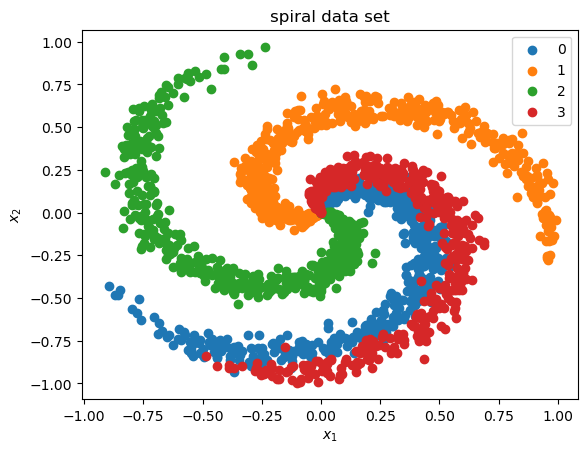

In [7]:
PlotClasses(X, Y)

In the next steps, we split the dataset and scale it as we did in the other modules.

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2)

In [9]:
scaler   = StandardScaler()
X_trainS = scaler.fit_transform(X_train)
X_testS  = scaler.transform(X_test)

<br>

# 3) The Model

**3.1) Building the Model**

We are now creating the ANN using ```Keras```. In the simplest version, we need an<br> 
<br>
- input layer ingesting the data,<br>
- add an activation function and<br>
- an output layer.<br>

Here, since we are working on a classification problem, the output layer needs to have a ```softmax``` activation function at the end (see lecture). Using the ```softmax``` activation function, we **turn the output of the output layer into probabilities** for the class assignments for each data point. Therefore, the output layer needs ```NClasses``` output neurons: each neuron will be voting for each of the five classes.

In [10]:
# One-hot encoding of the classes/labels for Keras
Y_train_oh = keras.utils.to_categorical(Y_train, NClasses)
Y_test_oh  = keras.utils.to_categorical(Y_test, NClasses)

In [11]:
print(Y_test_oh[:10,:])

[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]]


In [12]:
Nneuron  = 64 # we provide a number of neurons for the input layer --> you can try to explore model performance for Nneuron = 2, 5, 10, etc

Buliding the actual model (minimal setup):

In [13]:
def My_Keras_Model(Nneuron, NClasses):
    return keras.Sequential([
        layers.Dense(Nneuron,  activation = 'relu'),
        layers.Dense(NClasses, activation = 'softmax')
    ])

In [14]:
keras_model = My_Keras_Model(Nneuron, NClasses)

Next, we pick ```Adam``` as an optimizer (see Module 14). Since we want to predict labels of data points via probabilities, we pick the categorical cross entropy $S$<br>
<br>
$S = \frac{1}{N}\sum_{n = 1}^N \sum_{i = 1}^{N_{class}}\,p_{i,n}(true)\,\,log\left[p_{i,n}(pred)\right]$<br>
<br>
as objective function. Here, $N$ is the total number of data points, $p_{i,n}(true)$ is the probability for the actual, true label (i. e. equals $1$ if true and $0$ if false) of data point $n$ and $p_{i,n}(pred)$ is the probability of class $i$ as predicted by the model. 

The greater $S$, the creater the **loss**, i. e. the goal is to find the minimum of $S$.

In [15]:
keras_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy')

<br>

**3.2) Training the Model**

We are ready to train the model now. While running the training, we split the training data into actual training data and validation data (usually 80/20) so that we can monitor the loss for both data sets. The information will be stored in the output ususally denoted as *history*. 

In [16]:
Nepochs = 300 #number of iterative training steps aka epochs

In [17]:
history = keras_model.fit(X_trainS, Y_train_oh, epochs = Nepochs, validation_split = 0.2)

Epoch 1/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3184 - val_loss: 1.2511
Epoch 2/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1949 - val_loss: 1.1550
Epoch 3/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1218 - val_loss: 1.0942
Epoch 4/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0742 - val_loss: 1.0541
Epoch 5/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0412 - val_loss: 1.0240
Epoch 6/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0167 - val_loss: 1.0016
Epoch 7/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9931 - val_loss: 0.9782
Epoch 8/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9720 - val_loss: 0.9561
Epoch 9/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9511 - val_loss: 0.9357
Epoch 10/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9306 - val_loss: 0.9173
Epoch 11/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9095 - val_loss: 0.8951
Epoch 12/300
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8

Both, the validation and the training loss drop the same way. That is good news, but it is nicer to visualize that via a line plot.

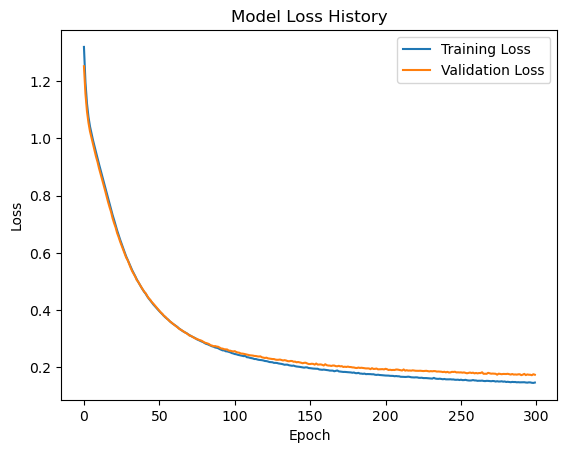

In [18]:
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label ='Validation Loss')
plt.title('Model Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

<br>

**3.3) Evaluating the Model**

Usually, we would now run the ```predict``` method now, but before we are going to do that, we want to visualize how the model learns the labels. Therefore, we re-run the training now, but this time we are going to make "snapshots" of the decission boundaries.<br>
<br>

3.3.1) Visualization of the learning process

Setting epoch marks for snapshots:

In [19]:
epoch_marks = [1, 5, 10, 20, 50, 100, 200, 500]
snapshots   = [None]*len(epoch_marks)

Resetting the model so that we start from $epoch=1$ again:

In [20]:
keras_model = My_Keras_Model(Nneuron, NClasses)
keras_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy')

Running training again and save snapshots:

In [21]:
ecurrent = 0
for e, epoch in enumerate(epoch_marks):
    
    keras_model.fit(X_trainS, Y_train_oh, epochs = epoch - ecurrent, verbose = 0)
    ecurrent = epoch
    print(f"current epoch: {epoch}")
    xx, yy, Z    = Compute_Boundary(X_trainS, keras_model)
    snapshots[e] = (epoch, xx, yy, Z)

current epoch: 1
current epoch: 5
current epoch: 10
current epoch: 20
current epoch: 50
current epoch: 100
current epoch: 200
current epoch: 500


Plotting decission boundaries as a function of epochs:

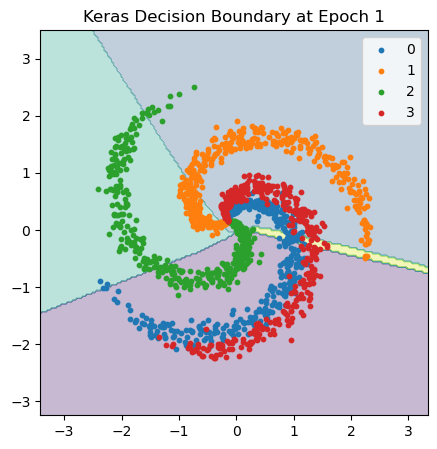

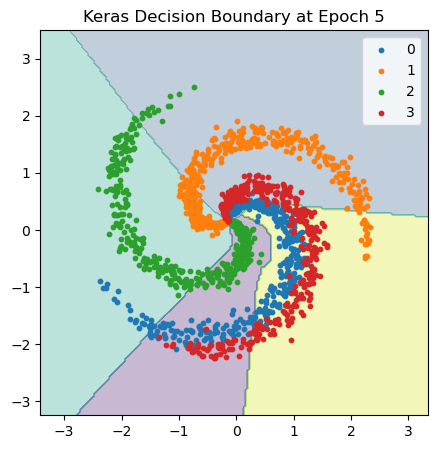

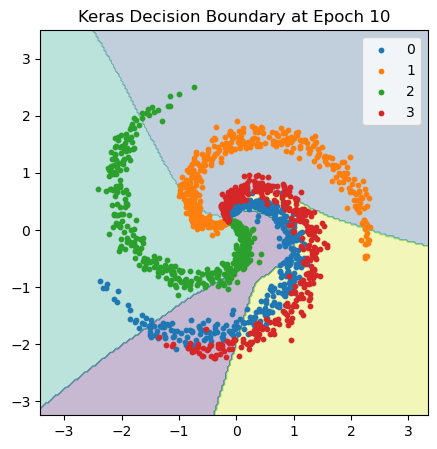

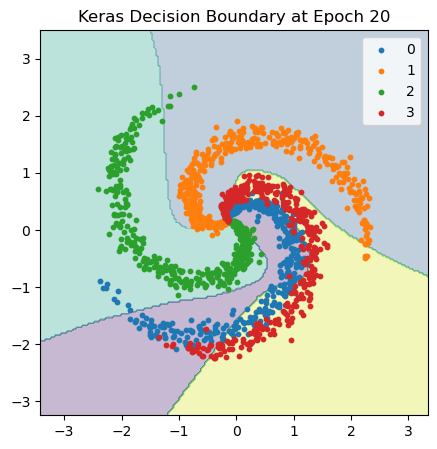

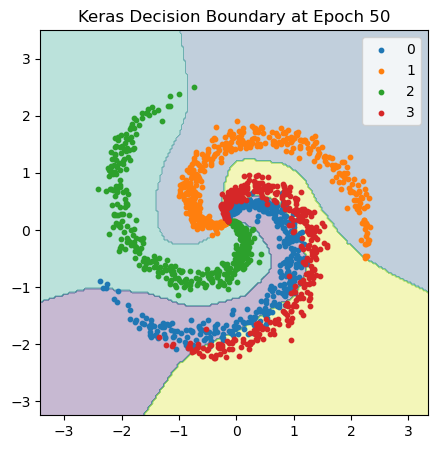

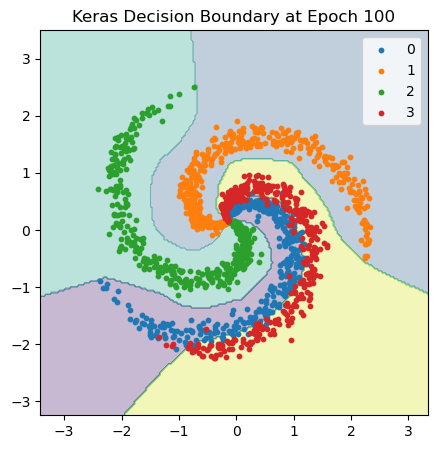

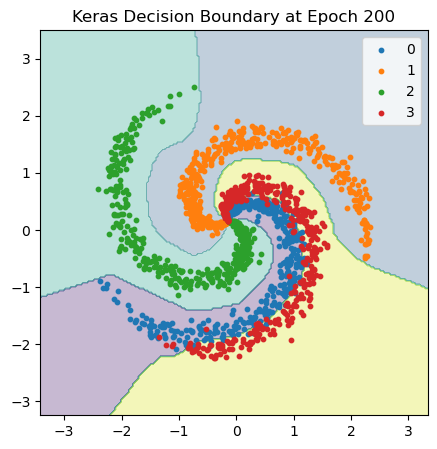

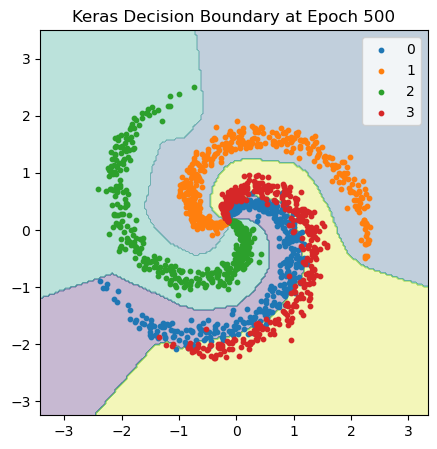

In [22]:
# Plot snapshots
for epoch, xx, yy, Z in snapshots:
    Plot_Boundary_Snapshot(X_trainS, Y_train, xx, yy, Z, f"Keras Decision Boundary at Epoch {epoch}")

<br>
3.3.2) Evaluation

Next, we take the test data set in order to predict the labels and compare the predictions to the true labels as we did with in the case of the other methods by generating a histogram of the probabilities and a confusion chart.

In [23]:
P = keras_model.predict(X_testS) # run prediction

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [24]:
Labels    = ["Class " + str(c) for c in range(NClasses)] # labels for plotting
LablesNum = list(np.arange(NClasses))

In [25]:
PredY = np.argmax(P, axis = 1) # picking predicted class as the most likely one

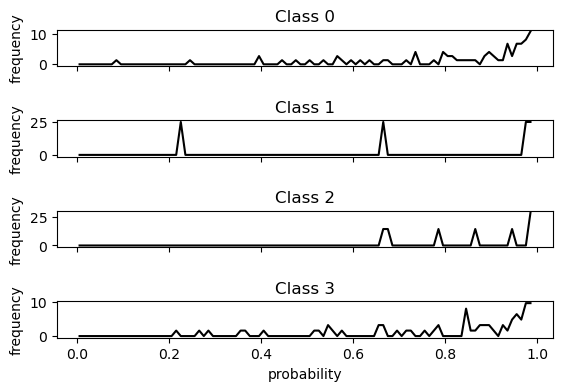

In [26]:
plot_entropy(P, Y_test, Labels, LablesNum)

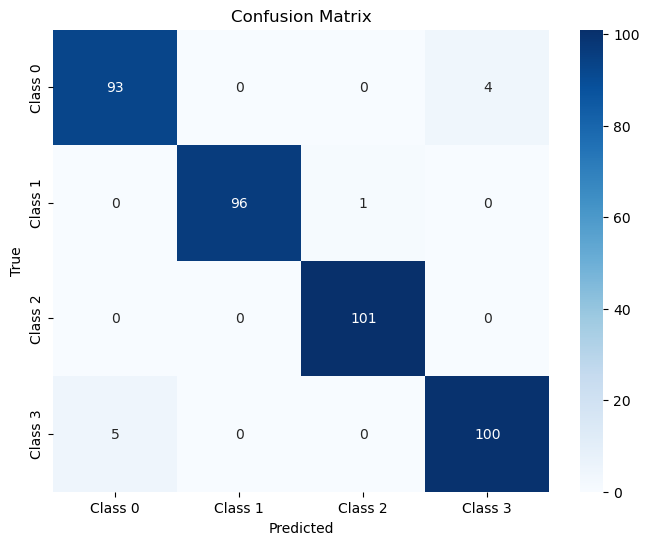

In [27]:
plot_confusion(PredY, Y_test, Labels)